In [1]:
import seaborn as sns
from sklearn.datasets import load_iris # import the "iris" dataset from sklearn as itss pre encoded and good for training
import pandas as pd
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

---
## <u>Load Dataset</u>

- we generally use the iris flower dataset for classification but also can use it for clustering
- the dataset has 3 categories of flowers : setosa, virginica and versicolor
- Key findings about the dataset:-
    - setosa is linearly separable i.e. its features are completely different from the other 2
    - viginica and versicolor are kinda correlated
    - when we plot it on scatter plot, setosa cluster will be completely different from virginica and versicolor


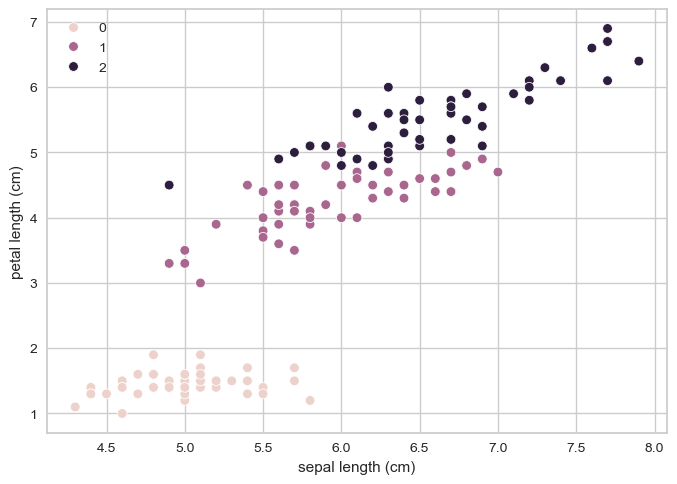

In [2]:
flower_data = load_iris() # directly loads data
X = pd.DataFrame(flower_data.data) # directly separates features in numpy ND array but we convert to pandas
y = flower_data.target # directly gives us labels in numpy 1d array

# currently our X doesnt have column names as we imported from sklearn, it is encoded into numbers, but we convert to actual names
X.columns = flower_data.feature_names

# X.head()

# we use iloc or loc with pd, loc is preffered when features have distinct names while iloc is shorter to write
sns.scatterplot( 
    x = X.iloc[:,0], 
    y = X.iloc[:,2],
    hue = y
) 

plt.grid(True)

---
## <u>Scaling</u>

In [3]:
scaler = StandardScaler()

scaler.set_output(transform="pandas")

X = scaler.fit_transform(X)

---
## <u>Find Value of K</u>

- **random_state** = doesn't remove randomness, it just locks in which random starting points get used so whenever we run the code we get the exact same result.
- **n_init** = how many different random starting points K-Means tries before picking the best one. More tries means less chance of getting stuck on a bad/unlucky start.
  
    - Together, n_init gives us a good result (by trying multiple random starts), random_state gives us a repeatable one (by freezing which starts get tried).
    - We want both, one without the other leaves us with either unstable or reproducibly stuck with a bad answer

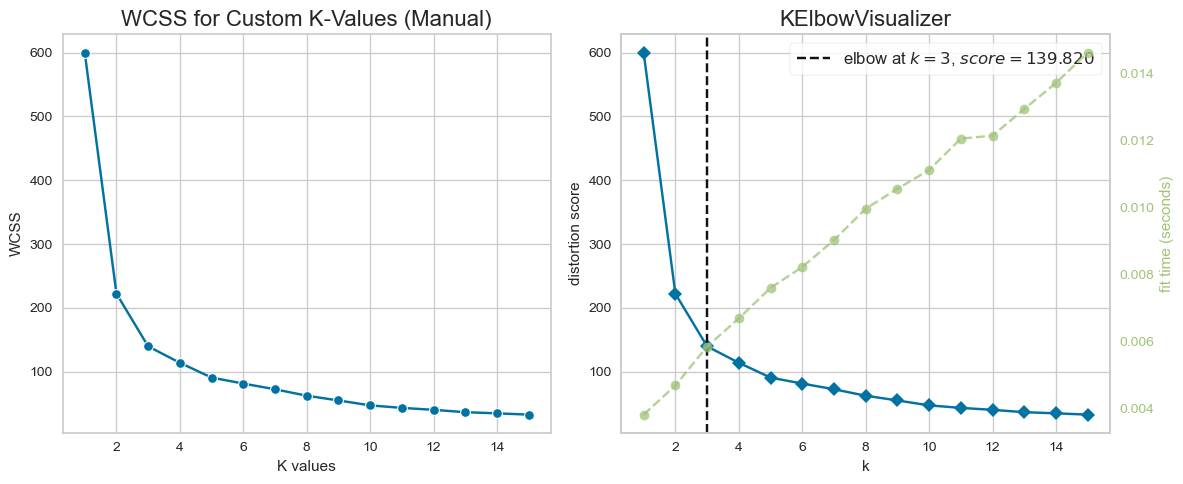

In [7]:
# define subplot
fig,ax = plt.subplots(1,2, figsize=(12,5))

# manually
wcss = []

for k in range(1,16): # check value of k from 1 to 15
    kmeans_elbow_model = KMeans( 
        n_clusters = k,
        random_state = 42, # reproducability
        n_init = 10        # try 10 different centroid seeds per K, keep the best
)
    kmeans_elbow_model.fit_predict(X)
    wcss.append(kmeans_elbow_model.inertia_)


# KElbowVisualizer
kmeans_visualize_model = KMeans(
    n_init = 10, 
    random_state = 42)
visualizer = KElbowVisualizer(
    kmeans_visualize_model, 
    k=(1,16),
    ax=ax[1]
)
visualizer.fit(X)

# plot for manual wcss
sns.lineplot(
    ax = ax[0],
    x = range(1,16),
    y = wcss,
    marker = "o"
)
ax[0].set_title("WCSS for Custom K-Values (Manual)", fontsize = 16)
ax[0].set_xlabel("K values")
ax[0].set_ylabel("WCSS")
ax[0].grid(True)

# plot for visualizer 
visualizer.finalize()
ax[1].set_title("KElbowVisualizer", fontsize=16)

plt.tight_layout()
plt.show()

# here we can see k can be 3

---
## <u>Create Model</u>

Text(0.5, 1.0, 'Predicted Clusters')

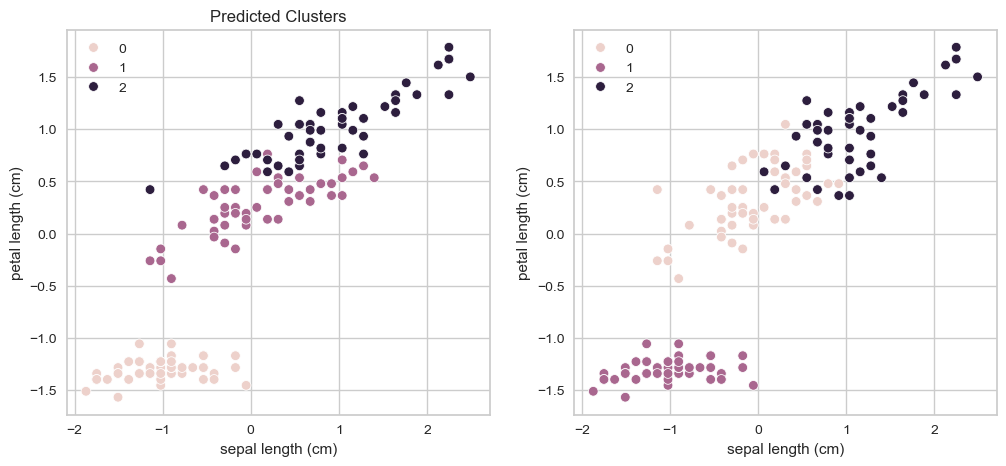

In [5]:
# create model using k = 3

kmeans_model = KMeans(n_clusters = 3,
                      random_state=42,
                      n_init = 10
)
labels = kmeans_model.fit_predict(X)

fig,ax = plt.subplots(1,2,figsize = (12,5))

sns.scatterplot(
    ax=ax[0],
    x = X.iloc[:,0],
    y = X.iloc[:,2],
    hue = y
)
ax[0].set_title("Actual Clusters")

sns.scatterplot(
    ax = ax[1],
    x = X.iloc[:,0],
    y = X.iloc[:,2],
    hue = labels
)
ax[0].set_title("Predicted Clusters")

---
## <u>Using PCA</u> [VERY IMP]

- PCA is an algorithm used for dimensionality reduction
- we can use pca to a great affect here as there are 4 dimensions (4d) and its pretty hard to visualise as well so we turn it into 2D


In [24]:
pca = PCA(n_components = 2) # as we finally wanna have 2d 
pca.set_output(transform = "pandas")
X_pca = pca.fit_transform(X)

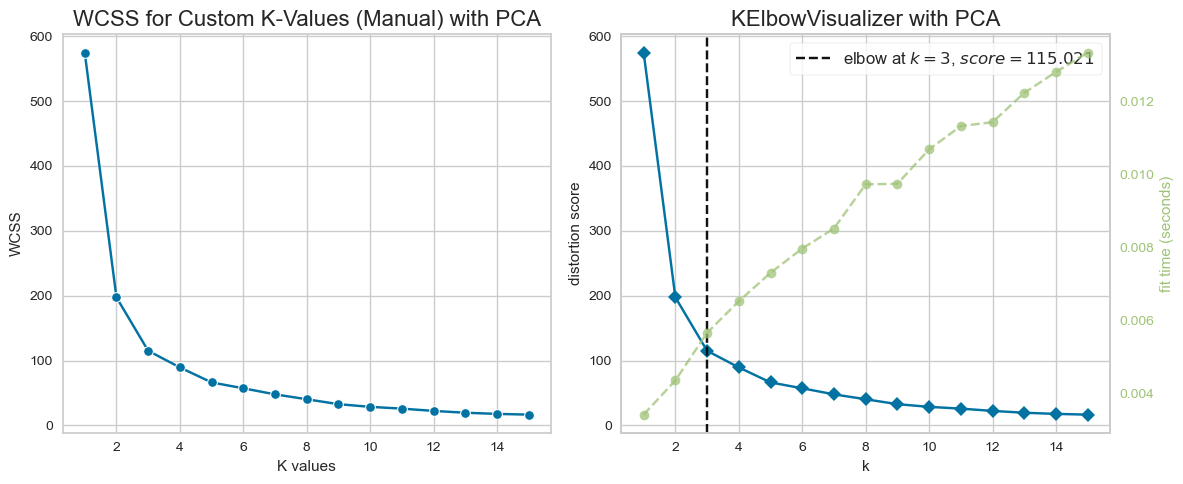

In [25]:
# find k again using elbow method but this time with X_pca

# define subplot
fig,ax = plt.subplots(1,2, figsize=(12,5))

# manually
wcss = []

for k in range(1,16): 
    kmeans_elbow_model = KMeans( 
        n_clusters = k,
        random_state = 42, 
        n_init = 10        
)
    kmeans_elbow_model.fit_predict(X_pca)  # using X_pca
    wcss.append(kmeans_elbow_model.inertia_)


# KElbowVisualizer
kmeans_visualize_model = KMeans(
    n_init = 10, 
    random_state = 42)
visualizer = KElbowVisualizer(
    kmeans_visualize_model, 
    k=(1,16),
    ax=ax[1]
)
visualizer.fit(X_pca) # using X_pca

# plot for manual wcss
sns.lineplot(
    ax = ax[0],
    x = range(1,16),
    y = wcss,
    marker = "o"
)
ax[0].set_title("WCSS for Custom K-Values (Manual) with PCA", fontsize = 16)
ax[0].set_xlabel("K values")
ax[0].set_ylabel("WCSS")
ax[0].grid(True)

# plot for visualizer 
visualizer.finalize()
ax[1].set_title("KElbowVisualizer with PCA", fontsize=16)

plt.tight_layout()
plt.show()

#### Make model with PCA data

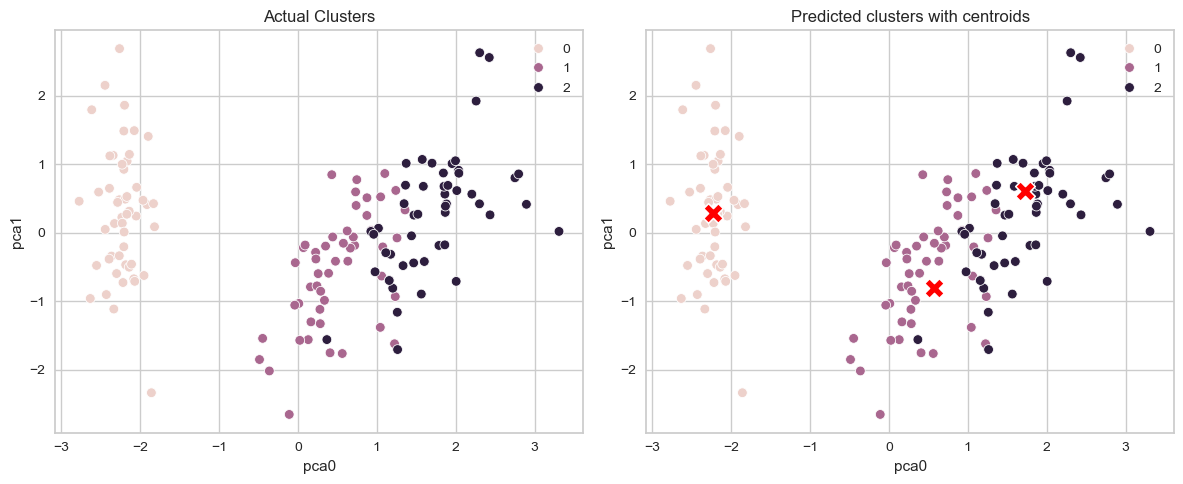

In [29]:
# make model
kmeans_model = KMeans(n_clusters = 3,
                      random_state = 42,
                      n_init = 10
)
labels = kmeans_model.fit_predict(X_pca)

# define figure
fig, ax = plt.subplots(1,2,figsize=(12,5))

# actual clusters
sns.scatterplot(
    ax = ax[0],
    x = X_pca.iloc[:,0], # using X_pca rather than X 
    y = X_pca.iloc[:,1], # cant use 2 here now as X_pca has only 2 dimensions
    hue = y
)
ax[0].set_title("Actual Clusters")

# predicted clusters
sns.scatterplot(
    ax=ax[1],
    x = X_pca.iloc[:,0],
    y = X_pca.iloc[:,1],
    hue = y
)

# we can also plot the centroids for each cluster
sns.scatterplot(
    ax=ax[1],
    x = kmeans_model.cluster_centers_[:,0],
    y = kmeans_model.cluster_centers_[:,1],
    marker = "X",
    c = "red", # color = red
    s = 200 # size = 200
)
ax[1].set_title("Predicted clusters with centroids")

plt.tight_layout()
plt.show()